# Practical Session: Linear Regression

**Intro to AI, Supervised Learning**

*Before doing anything you need to save a copy: File → Save a copy in Drive*

In this notebook you will:
1. Look at a small dataset of house sizes and prices.
2. Fit a line by hand by adjusting the parameters $w_0$ and $w_1$.
3. Let the computer find the best line for you.
4. Split the data into a training set and a test set.
5. Look at a second dataset where a line is not enough (underfitting).
6. See what happens when a model is too flexible (overfitting).

The linear model from the lecture is:

$$f(x) = w_0 + w_1 \cdot x$$

and the loss is the average squared loss:

$$L = \frac{1}{N} \sum_{i=1}^{N} (y_i - f(x_i))^2$$

## Setup

Run this cell first to load the libraries we need.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
from sklearn.linear_model import LinearRegression

np.random.seed(0)

## Part 1: Look at the data

We have a small dataset of houses. For each house we know its **size in square meters** and its **price in thousands of euros**. The goal is to learn a rule that predicts the price of a house from its size.

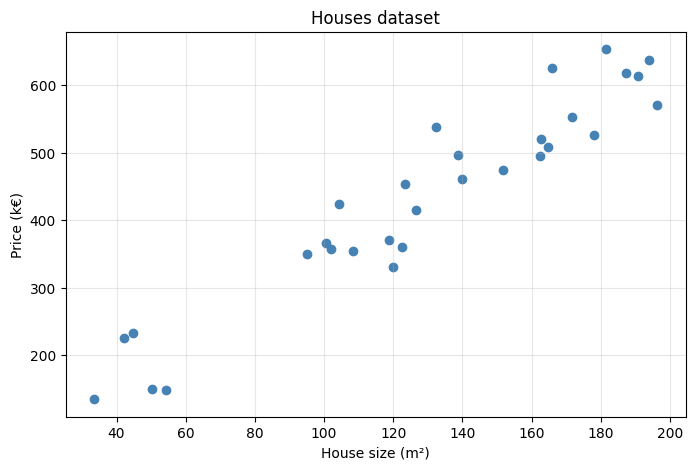

In [2]:
# Generate a small synthetic dataset (you do not need to read this cell)
N = 30
x = np.random.uniform(30, 200, size=N)
y = 50 + 3.0 * x + np.random.normal(0, 40, size=N)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='steelblue')
plt.xlabel('House size (m²)')
plt.ylabel('Price (k€)')
plt.title('Houses dataset')
plt.grid(True, alpha=0.3)
plt.show()

**Question:** From the plot, does it look like a straight line could describe this data reasonably well?

## Part 2: Fit a line by hand

The model is $f(x) = w_0 + w_1 \cdot x$. Move the two sliders to find values of $w_0$ and $w_1$ that make the loss (shown in the title) as small as possible.

- $w_1$ controls the slope of the line.
- $w_0$ controls the intercept (where the line crosses the y-axis).

In [3]:
@interact(
    w0=FloatSlider(min=-200, max=400, step=10, value=0, description='w₀'),
    w1=FloatSlider(min=-5, max=10, step=0.1, value=0, description='w₁'),
)
def plot_line(w0, w1):
    y_pred = w0 + w1 * x
    loss = np.mean((y - y_pred) ** 2)

    xs = np.linspace(x.min(), x.max(), 100)
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='steelblue', label='Data')
    plt.plot(xs, w0 + w1 * xs, 'r-', linewidth=2, label=f'f(x) = {w0:.0f} + {w1:.2f}·x')
    plt.xlabel('House size (m²)')
    plt.ylabel('Price (k€)')
    plt.title(f'Loss = {loss:.1f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

interactive(children=(FloatSlider(value=0.0, description='w₀', max=400.0, min=-200.0, step=10.0), FloatSlider(…

**Write down your best values:**

- Best $w_0$ = 10.00
- Best $w_1$ = 3.30
- Best loss = 2268.8

Searching for parameters that minimize the loss is what we call **training** in machine learning.

## Part 3: Let the computer do it

The best $w_0$ and $w_1$ can be computed automatically. For linear regression with squared loss there is even a closed-form solution, so no search is needed.

w₀ = 53.53,  w₁ = 2.94
Loss = 1971.09


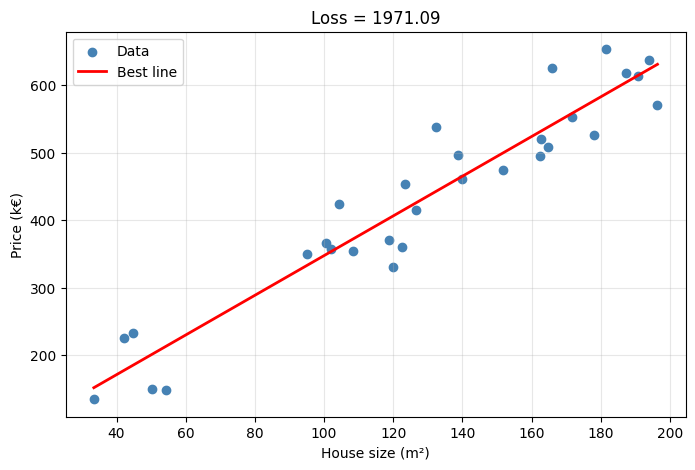

In [4]:
model = LinearRegression()
model.fit(x.reshape(-1, 1), y)

w0_best = model.intercept_
w1_best = model.coef_[0]
y_pred = model.predict(x.reshape(-1, 1))
loss_best = np.mean((y - y_pred) ** 2)

print(f'w₀ = {w0_best:.2f},  w₁ = {w1_best:.2f}')
print(f'Loss = {loss_best:.2f}')

xs = np.linspace(x.min(), x.max(), 100)
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='steelblue', label='Data')
plt.plot(xs, w0_best + w1_best * xs, 'r-', linewidth=2, label='Best line')
plt.xlabel('House size (m²)')
plt.ylabel('Price (k€)')
plt.title(f'Loss = {loss_best:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Compare:** How close did your hand-tuned values get to the ones the computer found?

## Part 4: Training error vs. test error

So far we measured the loss on the same data we used to fit the model. But what we really care about is how well the model predicts the price of **new, unseen houses**.

To check this, we split our data:
- **Training set**: used to fit the model.
- **Test set**: kept aside, only used at the end to check performance.

The split is done for you in the next cell.

Training loss: 2183.15
Test loss:     1557.52


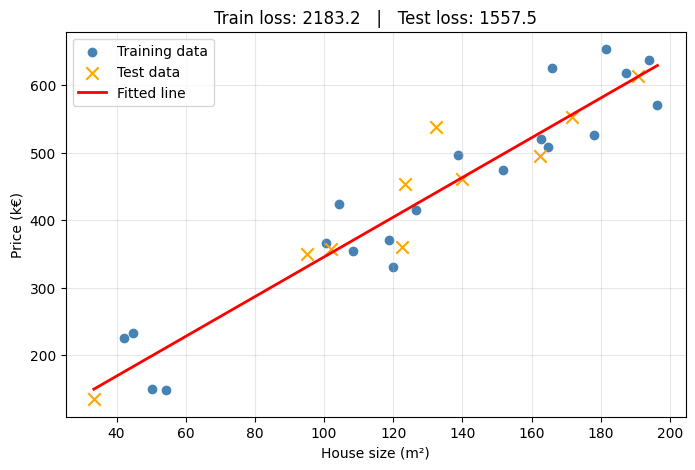

In [5]:
# 20 houses for training, 10 for testing
indices = np.random.permutation(N)
train_idx, test_idx = indices[:20], indices[20:]
x_train, y_train = x[train_idx], y[train_idx]
x_test, y_test = x[test_idx], y[test_idx]

# Fit on the training set only
model = LinearRegression()
model.fit(x_train.reshape(-1, 1), y_train)

# Compute losses on both sets
train_loss = np.mean((y_train - model.predict(x_train.reshape(-1, 1))) ** 2)
test_loss = np.mean((y_test - model.predict(x_test.reshape(-1, 1))) ** 2)

print(f'Training loss: {train_loss:.2f}')
print(f'Test loss:     {test_loss:.2f}')

xs = np.linspace(x.min(), x.max(), 100)
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, color='steelblue', label='Training data')
plt.scatter(x_test, y_test, color='orange', marker='x', s=80, label='Test data')
plt.plot(xs, model.predict(xs.reshape(-1, 1)), 'r-', linewidth=2, label='Fitted line')
plt.xlabel('House size (m²)')
plt.ylabel('Price (k€)')
plt.title(f'Train loss: {train_loss:.1f}   |   Test loss: {test_loss:.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Question:** Is the test loss higher or lower than the training loss? Why might that be?

*Your answer:* Test loss is lower which can happen due to the small Test Dataset and/or "easier" Test Data beeing more predictable.

## Part 5: When a line is not enough

The houses dataset was well captured by a straight line. Many real datasets are not.

Here is a second example: **crop yield as a function of fertilizer applied**. With too little fertilizer the plants do not grow well; with too much, they suffer.

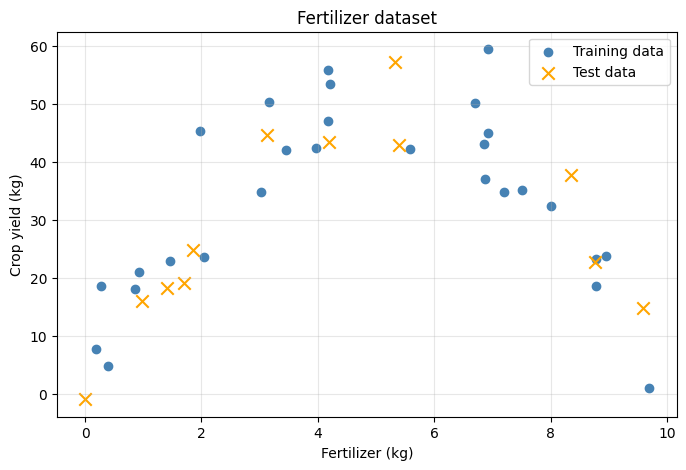

In [6]:
# Generate a second, nonlinear dataset (you do not need to read this cell)
np.random.seed(1)
N2 = 40
x2 = np.random.uniform(0, 10, size=N2)
y2 = -2.0 * (x2 - 5) ** 2 + 50 + np.random.normal(0, 8, size=N2)

indices2 = np.random.permutation(N2)
train_idx2, test_idx2 = indices2[:28], indices2[28:]
x2_train, y2_train = x2[train_idx2], y2[train_idx2]
x2_test, y2_test = x2[test_idx2], y2[test_idx2]

plt.figure(figsize=(8, 5))
plt.scatter(x2_train, y2_train, color='steelblue', label='Training data')
plt.scatter(x2_test, y2_test, color='orange', marker='x', s=80, label='Test data')
plt.xlabel('Fertilizer (kg)')
plt.ylabel('Crop yield (kg)')
plt.title('Fertilizer dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Question:** Could a straight line describe this data well? Why or why not?

Let's fit one and see.

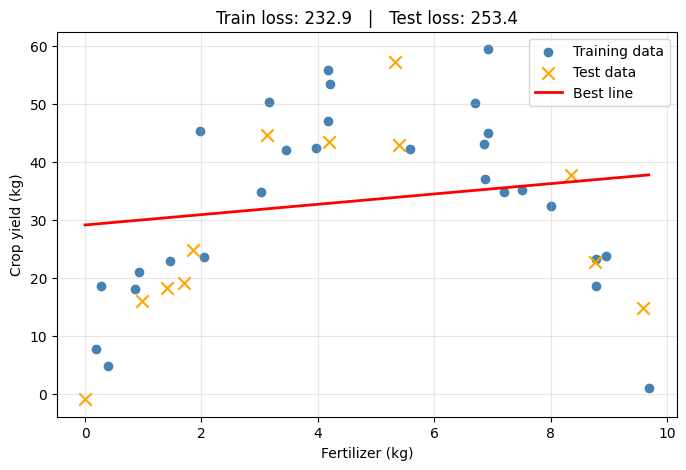

In [7]:
model2 = LinearRegression()
model2.fit(x2_train.reshape(-1, 1), y2_train)

train_loss2 = np.mean((y2_train - model2.predict(x2_train.reshape(-1, 1))) ** 2)
test_loss2 = np.mean((y2_test - model2.predict(x2_test.reshape(-1, 1))) ** 2)

xs2 = np.linspace(x2.min(), x2.max(), 100)
plt.figure(figsize=(8, 5))
plt.scatter(x2_train, y2_train, color='steelblue', label='Training data')
plt.scatter(x2_test, y2_test, color='orange', marker='x', s=80, label='Test data')
plt.plot(xs2, model2.predict(xs2.reshape(-1, 1)), 'r-', linewidth=2, label='Best line')
plt.xlabel('Fertilizer (kg)')
plt.ylabel('Crop yield (kg)')
plt.title(f'Train loss: {train_loss2:.1f}   |   Test loss: {test_loss2:.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Even the best-fitting line cannot capture the shape of the data. Both the training loss and the test loss are high.

This is **underfitting**: the model is too simple for the underlying pattern. We need a more flexible model.

## Part 6: A more flexible model

The helper function `fit_and_plot` fits a curve of a given **complexity**:
- `complexity=1`: a straight line, like before.
- Higher values: more flexible, wigglier curves.

Run the next cell to define it. You do not need to read its code.

In [8]:
def fit_and_plot(x_train, y_train, x_test, y_test, complexity,
                 xlabel='x', ylabel='y'):
    mu, sigma = x_train.mean(), x_train.std()
    xn_train = (x_train - mu) / sigma
    xn_test = (x_test - mu) / sigma

    coeffs = np.polyfit(xn_train, y_train, deg=complexity)

    train_loss = np.mean((y_train - np.polyval(coeffs, xn_train)) ** 2)
    test_loss = np.mean((y_test - np.polyval(coeffs, xn_test)) ** 2)

    xs = np.linspace(x_train.min(), x_train.max(), 300)
    xsn = (xs - mu) / sigma

    all_y = np.concatenate([y_train, y_test])
    plt.figure(figsize=(8, 5))
    plt.scatter(x_train, y_train, color='steelblue', label='Training data')
    plt.scatter(x_test, y_test, color='orange', marker='x', s=80, label='Test data')
    plt.plot(xs, np.polyval(coeffs, xsn), 'r-', linewidth=2,
             label=f'Model (complexity={complexity})')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f'Complexity {complexity}   |   Train loss: {train_loss:.1f}   |   Test loss: {test_loss:.1f}')
    plt.ylim(all_y.min() - 10, all_y.max() + 10)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### On the fertilizer dataset

On the fertilizer data the line was not enough. Let's see what more flexibility does.

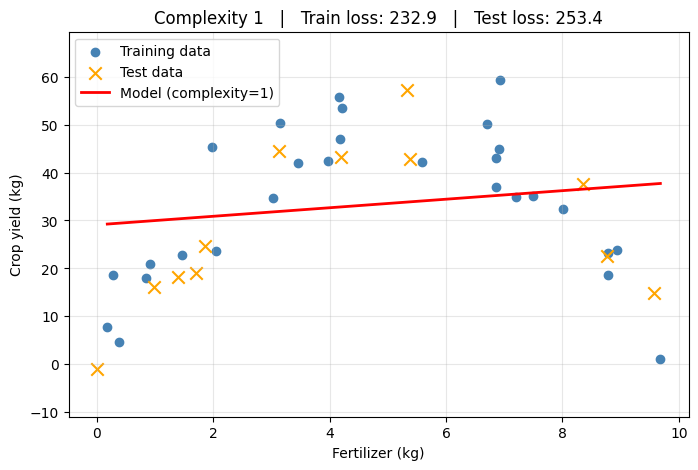

In [9]:
fit_and_plot(x2_train, y2_train, x2_test, y2_test, complexity=1,
             xlabel='Fertilizer (kg)', ylabel='Crop yield (kg)')

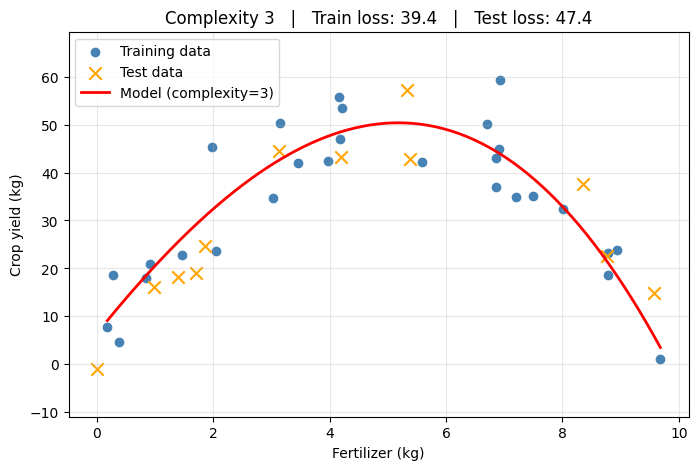

In [10]:
fit_and_plot(x2_train, y2_train, x2_test, y2_test, complexity=3,
             xlabel='Fertilizer (kg)', ylabel='Crop yield (kg)')

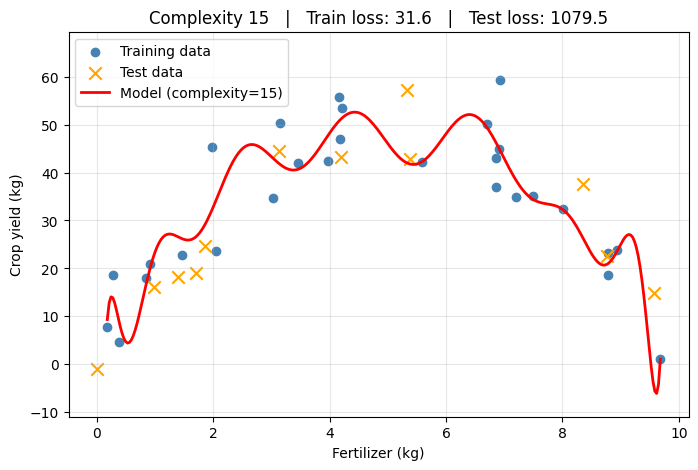

In [11]:
fit_and_plot(x2_train, y2_train, x2_test, y2_test, complexity=15,
             xlabel='Fertilizer (kg)', ylabel='Crop yield (kg)')

### On the houses dataset

On the houses data, the line was already a good fit. What happens if we use a more flexible model anyway?

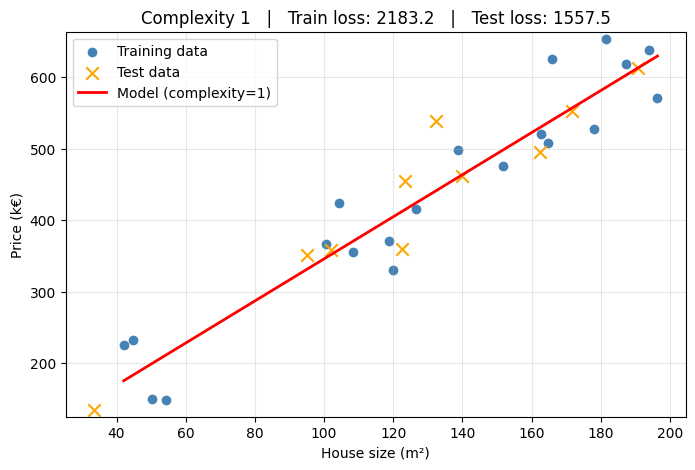

In [12]:
fit_and_plot(x_train, y_train, x_test, y_test, complexity=1,
             xlabel='House size (m²)', ylabel='Price (k€)')

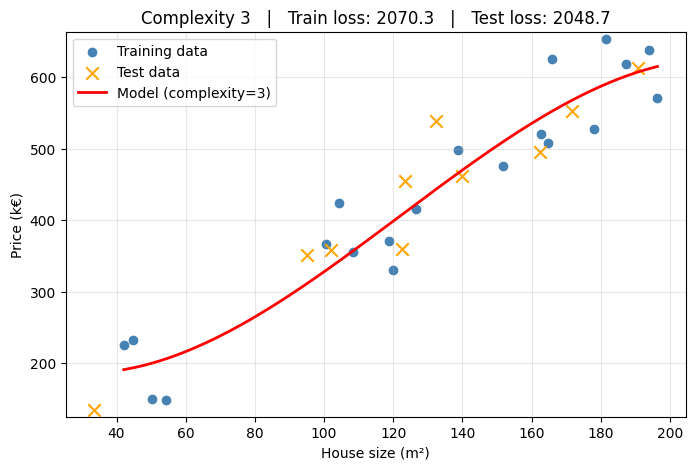

In [13]:
fit_and_plot(x_train, y_train, x_test, y_test, complexity=3,
             xlabel='House size (m²)', ylabel='Price (k€)')

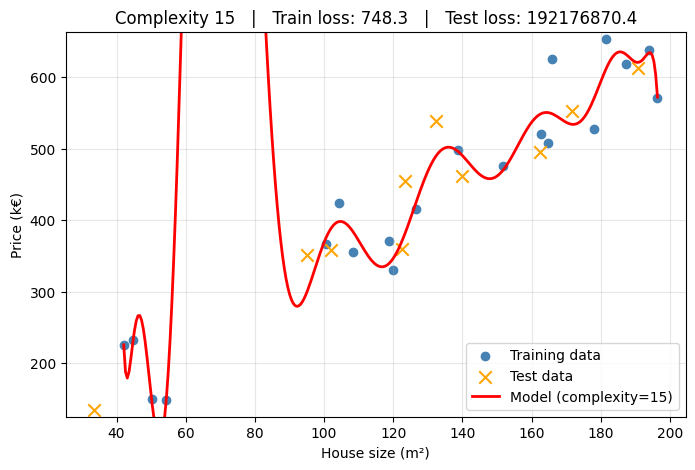

In [14]:
fit_and_plot(x_train, y_train, x_test, y_test, complexity=15,
             xlabel='House size (m²)', ylabel='Price (k€)')

### Explore with sliders

Use the sliders below to vary complexity on each dataset and compare.

In [15]:
@interact(complexity=IntSlider(min=1, max=18, step=1, value=1, description='fertilizer'))
def explore_fertilizer(complexity):
    fit_and_plot(x2_train, y2_train, x2_test, y2_test, complexity,
                 xlabel='Fertilizer (kg)', ylabel='Crop yield (kg)')

interactive(children=(IntSlider(value=1, description='fertilizer', max=18, min=1), Output()), _dom_classes=('w…

In [16]:
@interact(complexity=IntSlider(min=1, max=18, step=1, value=1, description='houses'))
def explore_houses(complexity):
    fit_and_plot(x_train, y_train, x_test, y_test, complexity,
                 xlabel='House size (m²)', ylabel='Price (k€)')

interactive(children=(IntSlider(value=1, description='houses', max=18, min=1), Output()), _dom_classes=('widge…

## Wrap-up questions

Discuss in pairs and write your answers below.

1. For the **fertilizer** dataset, which complexity gave the lowest training loss? Which gave the lowest test loss?
2. For the **houses** dataset, which complexity gave the lowest training loss? Which gave the lowest test loss?
3. If you only looked at training loss, which model would you pick on each dataset? Would that be a good choice?
4. In your own words: what is **underfitting**? When does it happen?
5. In your own words: what is **overfitting**? When does it happen?
6. Why was a straight line a good model for the houses dataset, but not for the fertilizer dataset?

*Your answers:*

1. lowest training loss with complexity = 15, lowest test loss with complexity = 3.
2. lowest training loss with complexity = 15, lowest test loss with complexity = 1.
3. Model with complexity = 15 (high complexity) to reduce training loss and fit training data. It wouldn't be a good choice for the test loss due to overfitting.
4. Underfitting is when our model doesn't fit the training data leading to high training loss which also leads to high test loss as it doesn't capture the underlying patterns.
5. Overfitting is when our model fits the training data "too tightly" leading to low training loss but potentially leading to high test loss as it remebers the training data instead of capturing the underlying patterns.
6. Because of the nature of the relationship of the input and output. While in the house dataset the relationship is proportional and monotic, increasing the house size increases the price, the fertilizer dataset relationship of the input and output is not, at some point increasing the fertilizer amount decreases the crop amount which is better fit by a parabola.